In [8]:
import pyro
import pyro.distributions as dist
import torch
import torch.nn.functional as F
from pyro.infer import SVI, Trace_ELBO
from pyro.optim import Adam
from pyro import poutine
from pyro.distributions import constraints
from pyro.infer.autoguide import AutoDiagonalNormal
from pyro.infer import config_enumerate
import tqdm
import numpy as np
import seaborn
import matplotlib.pyplot as plt
import scvi
import scanpy as sc
import anndata
import pandas as pd
import scipy
from collections import defaultdict
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

if torch.cuda.is_available():
    print("GPU is available")
    print("Number of GPUs:", torch.cuda.device_count())
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is not available")

import antipode

GPU is available
Number of GPUs: 1
GPU Name: NVIDIA TITAN X (Pascal)


In [5]:
# Set random seed for reproducibility
pyro.set_rng_seed(0)

# Define constants
n_latent = 6
n_var = 250
n_components = 7
n_datapoints = 100000
locs_range = 4
batch_size = 32

In [ ]:
torch.distributions.

In [106]:
import math
import torch
from torch.distributions import constraints
from torch.distributions.utils import broadcast_all
from torch.distributions.transformed_distribution import TransformedDistribution
from torch.distributions.transforms import ExpTransform
from pyro.distributions import TorchDistribution

def logaddexp(tensor, other):
    a = torch.max(tensor, other)
    return a + ((tensor - a).exp() + (other - a).exp()).log()
    
def logsubstractexp(tensor, other):
    a = torch.max(tensor, other) - (1 / (tensor-other+torch.finfo().tiny)).log()
    return a + ((tensor - a).exp() - (other - a).exp() ).log()
    #return a + (torch.clamp((tensor - a).exp() - (other - a).exp(),min=torch.finfo().tiny) ).log()

def logsubstractexp(log_a, log_b):
    """
    Numerically stable computation of log(a - b) given log_a = log(a) and log_b = log(b).
    Requires that log_a >= log_b.
    """
    # Ensure that log_a >= log_b to avoid negative arguments in log1p
    result = log_a + torch.log1p(-torch.exp(log_b - log_a))
    return result

class LogLogistic(TransformedDistribution):
    r"""
    Creates a log-logistic distribution parameterized by
    :attr:`loc` and :attr:`scale` where::

        X ~ Logistic(loc, scale)
        Y = exp(X) ~ LogLogistic(loc, scale)

    Example::

        >>> # xdoctest: +IGNORE_WANT("non-deterministic")
        >>> m = LogLogistic(torch.tensor([0.0]), torch.tensor([1.0]))
        >>> m.sample()  # log-logistic distributed with mean=0 and stddev=1
        tensor([ 0.1046])

    Args:
        loc (float or Tensor): mean of log of distribution
        scale (float or Tensor): standard deviation of log of the distribution
    """
    arg_constraints = {"loc": constraints.real, "scale": constraints.positive}
    support = constraints.nonnegative
    has_rsample = True

    def __init__(self, loc, scale, validate_args=None):
        base_dist = dist.Logistic(loc, scale, validate_args=validate_args)
        super().__init__(base_dist, ExpTransform(), validate_args=validate_args)

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(LogLogistic, _instance)
        return super().expand(batch_shape, _instance=new)

    @property
    def loc(self):
        return self.base_dist.loc

    @property
    def scale(self):
        return self.base_dist.scale

    @property
    def mean(self):
        # Note: This is an approximation; the exact mean of a log-logistic distribution is not straightforward
        return (self.loc + (math.pi / 2 * self.scale).pow(2) / 2).exp()

    @property
    def mode(self):
        return (self.loc - (math.pi / 2 * self.scale).pow(2)).exp()

    @property
    def variance(self):
        # This is an approximation for the variance
        scale_sq = (math.pi / 2 * self.scale).pow(2)
        return scale_sq.expm1() * (2 * self.loc + scale_sq).exp()

    def entropy(self):
        return self.base_dist.entropy() + self.loc

    def log_cdf(self, value, epsilon=1e-10):
        if self._validate_args:
            self._validate_sample(value)
        value = torch.clamp(value,min=torch.finfo().tiny)
        z = (torch.log(value) - self.loc) / self.scale
        return torch.nn.functional.logsigmoid(z)

class FlooredLogLogistic(TorchDistribution):
    """
    Floored Log-Logistic distribution.

    This distribution corresponds to flooring the samples from a Log-Logistic distribution, 
    making the distribution discrete. The pdf is computed as the difference of the cdf between 
    each integer and the next.

    :param loc: Location parameter.
    :param scale: Scale parameter.
    """

    arg_constraints = {"loc": constraints.real, "scale": constraints.positive}
    support = constraints.nonnegative
    has_rsample = True

    def __init__(self, loc, scale, *, validate_args=None):
        self.loc, self.scale = broadcast_all(loc, scale)
        self.base_dist = LogLogistic(loc, scale, validate_args=validate_args)
        super().__init__(self.loc.shape, validate_args=validate_args)

    def expand(self, batch_shape, _instance=None):
        new = self._get_checked_instance(FlooredLogLogistic, _instance)
        batch_shape = torch.Size(batch_shape)
        new.loc = self.loc.expand(batch_shape)
        new.scale = self.scale.expand(batch_shape)
        new.base_dist = self.base_dist.expand(batch_shape)
        super(FlooredLogLogistic, new).__init__(batch_shape, validate_args=False)
        new._validate_args = self._validate_args
        return new

    def log_prob(self, value):
        if self._validate_args:
            self._validate_sample(value)
        log_cdf_value_plus_1 = self.base_dist.log_cdf(value + 1)
        log_cdf_value = self.base_dist.log_cdf(value)
        return torch.clamp(logsubstractexp(logaddexp(log_cdf_value_plus_1 , (torch.finfo().tiny*log_cdf_value.new_ones(1)).log()), log_cdf_value),min=-100.,max=100.)
    
    # def log_prob(self, value):
    #     if self._validate_args:
    #         self._validate_sample(value)
    #     log_cdf_value_plus_1 = self.base_dist.cdf(value + 1)
    #     log_cdf_value = self.base_dist.cdf(value)
    #     return torch.clamp((log_cdf_value_plus_1-log_cdf_value).log(),min=-100.,max=0.)
    
    def rsample(self, sample_shape=torch.Size()):
        samples = self.base_dist.rsample(sample_shape)
        return torch.floor(samples)

    @property
    def mean(self):
        return torch.floor(self.base_dist.mean)

    @property
    def variance(self):
        # This is an approximation for the variance
        mean_floor = torch.floor(self.base_dist.mean)
        mean_floor_plus_1 = mean_floor + 1
        p_floor = self.base_dist.cdf(mean_floor_plus_1) - self.base_dist.cdf(mean_floor)
        return mean_floor * (1 - p_floor) + mean_floor_plus_1 * p_floor - self.mean ** 2

    def entropy(self):
        # Entropy computation for discretized distributions can be non-trivial
        raise NotImplementedError("Entropy is not implemented for FlooredLogLogistic")


In [107]:
# def logsubstractexp(tensor, other):
#     a = torch.max(tensor, other) - (1 / (tensor-other+torch.finfo().tiny)).log()
#     print(a)
#     print((tensor - a).exp())
#     print((other - a).exp())
#     return a + ((tensor - a).exp() - (other - a).exp() ).log()
#     #return a + (torch.clamp((tensor - a).exp() - (other - a).exp(),min=torch.finfo().tiny) ).log()

In [108]:
torch.nn.functional.logsigmoid(torch.tensor(1000.))

tensor(0.)

In [109]:
torch.clamp(logsubstractexp(logaddexp(torch.ones(1) , torch.tensor(-20.)), torch.ones(1)),min=-100.)

tensor([-100.])

<Axes: ylabel='Count'>

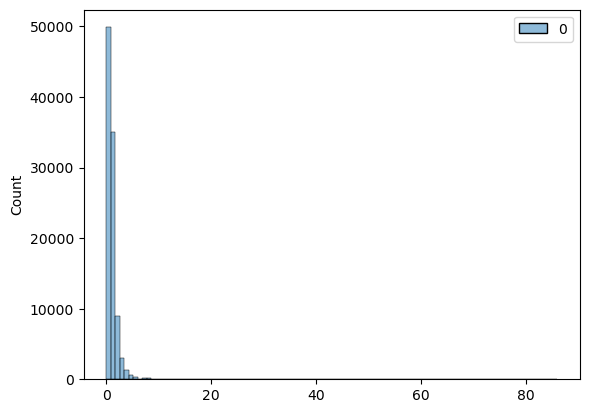

In [110]:
seaborn.histplot(FlooredLogLogistic(loc=torch.zeros(1),scale=0.4*torch.ones(1),validate_args=False).sample([100000]),bins=100)

<Axes: ylabel='Count'>

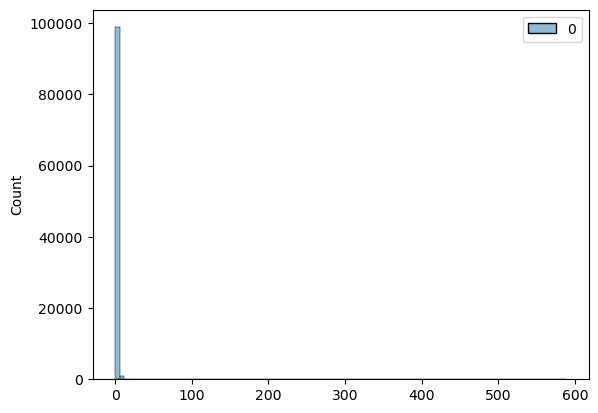

In [111]:
seaborn.histplot(FlooredLogLogistic(loc=torch.zeros(1),scale=0.4*torch.ones(1),validate_args=False).sample([100000]),bins=100)

<Axes: >

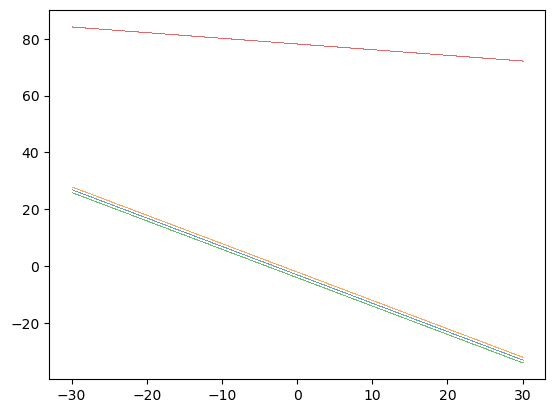

In [112]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
log_probs=LogLogistic(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

<Axes: xlabel='None', ylabel='None'>

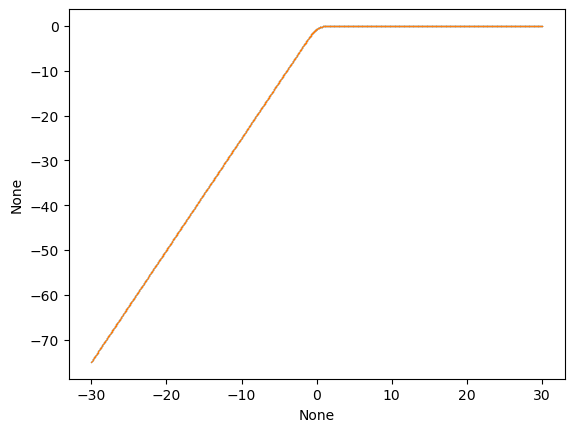

In [113]:
seaborn.scatterplot(x=mus.flatten(),y=LogLogistic(loc=torch.zeros(1),scale=0.4*torch.ones(1),validate_args=False).cdf(mus.exp().flatten()).log(),s=1,linewidth=0)
seaborn.scatterplot(x=mus.flatten(),y=LogLogistic(loc=torch.zeros(1),scale=0.4*torch.ones(1),validate_args=False).log_cdf(mus.exp().flatten()),s=1,linewidth=0)

<Axes: >

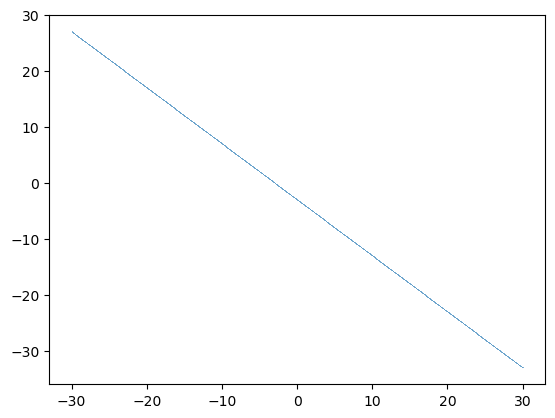

In [114]:
LogLogistic(loc=mus,scale=total_counts,validate_args=False)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)


<Axes: >

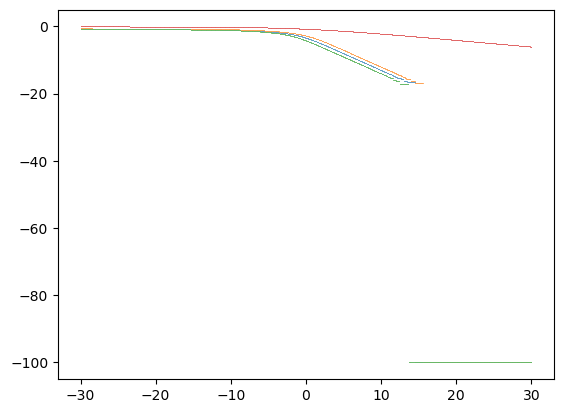

In [115]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
log_probs=FlooredLogLogistic(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

In [116]:
grads=defaultdict(list)

import pyro
import pyro.ops.jit
from pyro.distributions.util import is_identically_zero
from pyro.infer.elbo import ELBO
from pyro.infer.enum import get_importance_trace
from pyro.infer.util import (
    MultiFrameTensor,
    get_plate_stacks,
    is_validation_enabled,
    torch_item,
)
from pyro.util import check_if_enumerated, warn_if_nan

class SafeSVI(pyro.infer.abstract_infer.TracePosterior):
    '''A version of pyro.infer.SVI that skips steps with loss more than X sigma from the running mean loss'''
    def __init__(
        self,
        model,
        guide,
        optim,
        loss,
        loss_and_grads=None,
        clip_std_multiplier=6.0,
        window_size=1000,  # Default window size of 300
        **kwargs
    ):
        super().__init__(**kwargs)
        self.model = model
        self.guide = guide
        self.optim = optim
        self.record = False
        self.clip_std_multiplier = clip_std_multiplier
        self.window_size = window_size
        self.losses = []  # Store recent losses to calculate running stats

        if not isinstance(optim, pyro.optim.PyroOptim):
            raise ValueError("Optimizer should be an instance of pyro.optim.PyroOptim class.")

        if isinstance(loss, ELBO):
            self.loss = loss.loss
            self.loss_and_grads = loss.loss_and_grads
        else:
            if loss_and_grads is None:
                def _loss_and_grads(*args, **kwargs):
                    loss_val = loss(*args, **kwargs)
                    if getattr(loss_val, "requires_grad", False):
                        loss_val.backward(retain_graph=True)
                    return loss_val
                self.loss_and_grads = _loss_and_grads
            else:
                self.loss_and_grads = loss_and_grads

    def _traces(self, *args, **kwargs):
        for i in range(self.num_samples):
            guide_trace = poutine.trace(self.guide).get_trace(*args, **kwargs)
            model_trace = poutine.trace(
                poutine.replay(self.model, trace=guide_trace)
            ).get_trace(*args, **kwargs)
            yield model_trace, 1.0

    def evaluate_loss(self, *args, **kwargs):
        with torch.no_grad():
            loss = self.loss(self.model, self.guide, *args, **kwargs)
            return torch_item(loss)

    def step(self, *args, **kwargs):
        # Compute loss and gradients
        with poutine.trace(param_only=True) as param_capture:
            loss = self.loss_and_grads(self.model, self.guide, *args, **kwargs)
    
        loss_val = torch_item(loss)
        self.losses.append(loss_val)
        # Keep only the last `window_size` losses
        if len(self.losses) > self.window_size:
            self.losses.pop(0)
        # Extract params early to ensure they are defined for later use
        params = set(site["value"].unconstrained() for site in param_capture.trace.nodes.values())
        
        # Calculate running mean and std only if we have enough data
        if len(self.losses) >= self.window_size:
            running_mean = np.mean(self.losses)
            running_std = np.std(self.losses)
            #print(loss, running_mean,running_std)
            if ((loss > running_mean-running_std*self.clip_std_multiplier) and (loss < running_mean+running_std*self.clip_std_multiplier)):
                # Perform optimization step
                self.optim(params)
            else:
                print('STEP SKIPPED')
        else:
            self.optim(params)
        
        if self.record:
            for name, value in pyro.get_param_store().named_parameters():
                grads[name].append(value.grad.detach().cpu().numpy())
        
        # Zero gradients
        pyro.infer.util.zero_grads(params)
    
        return loss_val

In [117]:
def minmax(x):
    return(x.min(),x.max())

In [122]:
class ToyModel(torch.nn.Module):
    def __init__(self, n_latent=5, n_var=10, n_components=3):
        super(ToyModel, self).__init__()
        pyro.clear_param_store()
        self.n_latent = n_latent
        self.n_var = n_var
        self.n_components = n_components
        self.scale=1e-4
        # Assuming ZLEncoder and SimpleFFNN are defined elsewhere and imported
        self.encoder = antipode.train_utils.ZLEncoder(num_var=self.n_var, hidden_dims=[1000, 1000, 1000], outputs=[(self.n_latent, None), (self.n_latent, torch.nn.functional.softplus)])
        self.classifier = antipode.train_utils.SimpleFFNN(in_dim=self.n_latent, hidden_dims=[1000, 1000, 1000], out_dim=self.n_components)

    @config_enumerate
    def model(self, data=None):
        pyro.module("toy", self)
        device = data.device
        
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                l = data.sum(-1).unsqueeze(-1) + 1.
                
                # Ensure parameters are leaf tensors
                locs = pyro.param('locs', 0.1 * torch.randn(self.n_components, self.n_latent, device=device))
                scales = pyro.param('scales', 1.*torch.ones(self.n_components, self.n_latent, device=device), constraint=constraints.positive)
                transform_matrix = pyro.param('transform_matrix', 0.1 * torch.rand(self.n_latent, self.n_var, device=device))

                intercept = pyro.param('intercept', torch.zeros(self.n_components, self.n_var, device=device))
                total_counts = pyro.param('total_counts', 1 * torch.ones(self.n_var, device=device), constraint=constraints.positive)
                
                z = pyro.sample('z', dist.Categorical(logits=torch.ones(self.n_components, device=device),validate_args=True), infer={"enumerate": "parallel"})
                latent = pyro.sample('latent', dist.Normal(locs[z], scales[z]).to_event(1))
                out_mu = latent @ transform_matrix + intercept[z]
                norm_mu=torch.nn.functional.log_softmax(out_mu,dim=-1) + l.log()
                print('norm_mu',minmax(norm_mu))
                print(minmax(FlooredLogLogistic(loc=norm_mu,scale=total_counts,validate_args=True).log_prob(data)))
                pyro.sample('obs', FlooredLogLogistic(loc=norm_mu,scale=total_counts,validate_args=True).to_event(1), obs=data)


    def guide(self, data=None):
        pyro.module("toy", self)
        device = data.device
        with poutine.scale(scale=self.scale):
            with pyro.plate('batch', data.shape[0]):
                locs_mu, locs_std = self.encoder(data)
                latent = pyro.sample('latent', dist.Normal(locs_mu, locs_std,validate_args=True).to_event(1))
                weights_probs = pyro.sample('z', dist.Categorical(logits=self.classifier(latent),validate_args=True), infer={"enumerate": "parallel"})

In [123]:
# Generate synthetic data
def generate_synthetic_data(n_datapoints=5000,locs_range=2.):
    weights = torch.ones(n_components) / n_components
    locs = torch.randn(n_components, n_latent) * locs_range
    scales = torch.ones(n_components, n_latent) * 0.5
    transform_matrix = 1.*torch.randn(n_latent, n_var)
    intercept = 4*torch.rand(n_components, n_var)-2.
    overall_intercept = 12*torch.rand(n_var)-6.
    data = []
    true_clusters=[]
    true_latent=[]
    for _ in range(n_datapoints):
        l = 7 + 2*torch.rand(1)
        z = torch.multinomial(weights, 1).item()
        true_clusters.append(z)
        latent = torch.normal(locs[z], scales[z])
        true_latent.append(latent)
        out_mu = latent @ transform_matrix + intercept[z] + overall_intercept
        total_counts = torch.tensor(25.0)
        logits = (torch.softmax(out_mu,dim=-1)*l.exp()).log() - torch.log(total_counts) 
        counts = dist.NegativeBinomial(total_counts, logits=logits).sample()
        data.append(counts)
    
    return torch.stack(data),{'latent':true_latent,'clusters':true_clusters,'weights':weights,'locs':locs,'scales':scales,'intercept':intercept}

# Generate synthetic data
# data, true_params = generate_synthetic_data(n_datapoints=n_datapoints)
# adata=anndata.AnnData(X=data.cpu().numpy(),obs=pd.DataFrame([str(x) for x in true_params['clusters']],columns=['true_clusters']))
# adata.obsm['true_latents']=np.stack(true_params['latent'],axis=0)

In [124]:
toy_model = ToyModel(n_latent = n_latent+5,n_var = n_var,n_components = n_components+5)
toy_model.to(device)
grads=defaultdict(list)

# SVI setup
adam_params = {"lr": 0.005}
optimizer = Adam(adam_params)
svi = SafeSVI(toy_model.model, toy_model.guide, optimizer, loss=pyro.infer.TraceEnum_ELBO())

# Training loop
num_iterations = 30
losses = []

In [125]:
for i in tqdm.tqdm(range(num_iterations)):
    svi.record=True
    if i==num_iterations-1:
        svi.record=True

    loss = 0
    for j in range(0, n_datapoints, batch_size):
        batch = data[j:j+batch_size]
        loss = svi.step(batch.int().to(device))
        losses.append(loss)
    print(f"Iteration {i} : Loss {loss}")

print("Training complete.")

  0%|          | 0/30 [00:00<?, ?it/s]

norm_mu (tensor(1.1699, device='cuda:0', grad_fn=<MinBackward1>), tensor(4.0126, device='cuda:0', grad_fn=<MaxBackward1>))
(tensor(-14.2417, device='cuda:0', grad_fn=<MinBackward1>), tensor(-1.4402, device='cuda:0', grad_fn=<MaxBackward1>))
norm_mu (tensor(1.1721, device='cuda:0', grad_fn=<MinBackward1>), tensor(4.0929, device='cuda:0', grad_fn=<MaxBackward1>))
(tensor(-14.1549, device='cuda:0', grad_fn=<MinBackward1>), tensor(-1.4419, device='cuda:0', grad_fn=<MaxBackward1>))
norm_mu (tensor(1.0819, device='cuda:0', grad_fn=<MinBackward1>), tensor(3.7144, device='cuda:0', grad_fn=<MaxBackward1>))
(tensor(-14.2422, device='cuda:0', grad_fn=<MinBackward1>), tensor(-1.4099, device='cuda:0', grad_fn=<MaxBackward1>))
norm_mu (tensor(0.8321, device='cuda:0', grad_fn=<MinBackward1>), tensor(3.8625, device='cuda:0', grad_fn=<MaxBackward1>))
(tensor(-13.9323, device='cuda:0', grad_fn=<MinBackward1>), tensor(-1.1876, device='cuda:0', grad_fn=<MaxBackward1>))
norm_mu (tensor(1.0387, device='cuda

  0%|          | 0/30 [00:01<?, ?it/s]


ValueError: Expected parameter loc (Tensor of shape (32, 11)) of distribution Normal(loc: torch.Size([32, 11]), scale: torch.Size([32, 11])) to satisfy the constraint Real(), but found invalid values:
tensor([[nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan],
        [nan, nan, 

In [ ]:
antipode.plotting.plot_loss(losses)

In [ ]:
pyro.param('total_counts')

In [ ]:
toy_model.eval()
latents=[]
clusters=[]
for j in tqdm.tqdm(range(0, n_datapoints, batch_size)):
    batch = data[j:j+batch_size].to(device)
    latent=toy_model.encoder(batch)
    latents.append(latent[0].cpu().detach().numpy())
    component=toy_model.classifier(latent[0])
    clusters.append(component.cpu().detach().numpy())


In [ ]:
adata.obsm['rec_latents']=np.concatenate(latents,axis=0)
adata.obs['rec_clusters']=np.concatenate(clusters,axis=0).argmax(-1)
adata.obs['rec_clusters']=adata.obs['rec_clusters'].astype(str)

In [ ]:
out_locs = pyro.param('locs')
out_transform_matrix = pyro.param('transform_matrix')
out_intercept = pyro.param('intercept')
out_total_counts = pyro.param('total_counts')

# Compute the learned cluster means
learned_means = torch.nn.functional.log_softmax( out_locs @ out_transform_matrix + out_intercept ,dim=-1).detach().cpu().numpy()#+ (out_total_counts**2/2)
learned_means_clusters=[str(x) for x in range(learned_means.shape[0])]
#actual_means = true_params['locs'] @ true_params['transform_matrix'] + true_params['intercept']
actual_means = antipode.model_functions.group_aggr_anndata(adata,['rec_clusters'],normalize=True)
learned_means=learned_means[pd.Series(learned_means_clusters).isin(actual_means[1]['rec_clusters']),:]
actual_means=np.log(actual_means[0]+actual_means[0][actual_means[0]>0].min()*0.9)

In [132]:
zdw_grads=np.absolute(np.stack(grads['transform_matrix'])).mean(0)

Text(0, 0.5, 'abs gradient')

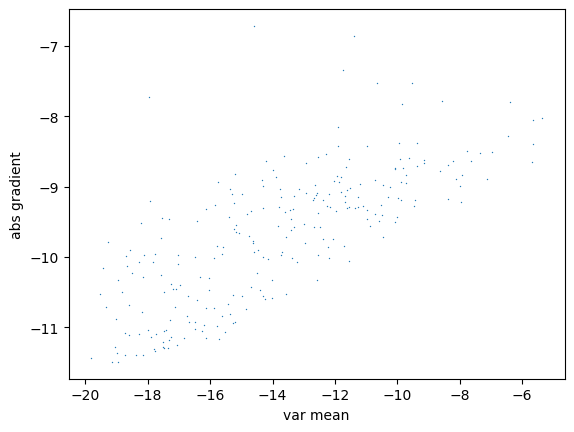

In [133]:
seaborn.scatterplot(x=actual_means.mean(0),y=np.log(zdw_grads.mean(0)),s=1)
plt.xlabel('var mean')
plt.ylabel('abs gradient')

In [ ]:
correlations = []
for i in range(toy_model.n_var):
    corr = np.corrcoef(actual_means[:, i], learned_means[:, i])[0, 1]
    correlations.append(corr)

# Plot a histogram of the correlations
plt.figure(figsize=(10, 6))
plt.hist(correlations, bins=20, edgecolor='k', alpha=0.7)
plt.xlabel('Correlation')
plt.ylabel('Frequency')
plt.title('Histogram of Correlation per Variable')
plt.show()

# Plot the relationship between the correlation and the cluster mean
plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), correlations, alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Correlation')
plt.title('Relationship Between Cluster Mean and Correlation')
plt.show()

plt.figure(figsize=(10, 6))
plt.scatter(actual_means.mean(axis=0), pyro.param('total_counts').cpu().detach().numpy(), alpha=0.7)
plt.xlabel('Cluster Mean')
plt.ylabel('Theta')
plt.show()


plt.figure(figsize=(10, 6))
x=learned_means.flatten()
y=actual_means.flatten()
seaborn.scatterplot(x=x,y=actual_means.flatten(),s=0.2,color='black')
seaborn.kdeplot(x=learned_means.flatten(),y=y,linestyles='--',color='teal', linewidths=0.5)
slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(x,y)

# Plot the regression line
x_values = np.linspace(np.min(x), np.max(x), 100)
plt.plot(x_values, slope * x_values + intercept, color='black', label=f'y={slope:.2f}x+{intercept:.2f}, R²={r_value**2:.2f}')
plt.title('Mean within species (species x clusters x genes')
# Add legend
plt.legend()
plt.ylabel('actual')
plt.xlabel('learned')
plt.show()


In [ ]:
adata.obsm['rec_mde']=scvi.model.utils.mde(adata.obsm['rec_latents'],init='random')
adata.obsm['true_mde']=scvi.model.utils.mde(adata.obsm['true_latents'],init='random')

In [ ]:
sc.pl.embedding(
    adata,
    basis='true_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)


In [ ]:
sc.pl.embedding(
    adata,
    basis='rec_mde',
    color=['true_clusters','rec_clusters'],
    palette=sc.pl.palettes.godsnot_102,
    legend_loc='on data'
)

In [ ]:
total_counts=5*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)


In [ ]:
log_probs=FlooredLogLogistic(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [ ]:
total_counts=(-5*torch.ones(1)).exp()
log_probs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.2)

In [ ]:
total_counts.exp()

In [ ]:
dist.NegativeBinomial(total_count=(torch.ones(1)+10).exp(),logits=torch.ones(1)+10,validate_args=False).sample([100000])

In [ ]:
for i in [-2,0,2,4]: 
    total_counts=-torch.tensor(10.)
    print(torch.tensor(i)-total_counts)
    print(torch.tensor(i).exp())
    seaborn.histplot(dist.NegativeBinomial(total_count=(total_counts).exp(),logits=torch.tensor(i)-total_counts,validate_args=False).sample([10000]),bins=100)

In [ ]:
total_counts=mus-10.
log_probs=dist.NegativeBinomial(total_count=total_counts.exp(),logits=mus-total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.2)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [ ]:
total_counts=mus-10.
log_probs=dist.Poisson(rate=mus.exp(),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0).exp())
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.2)

In [ ]:
total_counts=1*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
log_probs=dist.NegativeBinomial(total_count=total_counts,probs=total_counts/(mus.exp()+total_counts),validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1],dim=0).exp())

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.2)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.2)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [ ]:
log_probs=dist.LogNormal(loc=mus,scale=total_counts,validate_args=False).log_prob(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0).exp())

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)


In [ ]:
log_probs=dist.RelaxedBernoulli(temperature=0.0001*torch.ones(1),logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)],dim=0)))

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [ ]:
(
    -torch.lgamma(total_counts + 0)
    + torch.lgamma(1.0 + torch.zeros(1))
    + torch.lgamma(total_counts)
)

In [ ]:
print(dist.NegativeBinomial(total_count=s_theta,logits=logits).log_prob(torch.zeros(1)).exp())
print(dist.Bernoulli(,probs=1-((s_theta * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.zeros(1)).exp())

In [ ]:
print(dist.Bernoulli(,probs=1-((s_theta * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.zeros(1)).exp())

In [ ]:
-seaborn.scatterplot(x=logits.numpy().flatten(),y=(total_counts * torch.nn.functional.logsigmoid(logits)).numpy().flatten(),s=0.5)
plt.show()
seaborn.scatterplot(x=logits.numpy().flatten(),y=torch.logit((total_counts * torch.nn.functional.logsigmoid(-logits)).exp()).numpy().flatten(),s=0.5)


In [ ]:
logits=mus-total_counts.log()
log_probs=dist.Bernoulli(probs=1-((total_counts * torch.nn.functional.logsigmoid(-logits))).exp()).log_prob(torch.cat([mus.new_zeros(mus.shape),mus.new_ones(mus.shape)],dim=0))
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].exp().numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].exp().numpy().flatten(),s=0.5)


In [ ]:
log_probs=dist.Bernoulli(logits=mus,validate_args=False).log_prob(torch.sigmoid(torch.cat([mus,mus-1,mus+1,mus.new_zeros(mus.shape)-100],dim=0)))

In [ ]:
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=torch.sigmoid(mus).numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[0].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[1].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[2].numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=log_probs[3].numpy().flatten(),s=0.5)

In [ ]:
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[0]-log_probs[1]).numpy().flatten(),s=0.5)
seaborn.scatterplot(x=mus.numpy().flatten(),y=(log_probs[2]-log_probs[0]).numpy().flatten(),s=0.5)

In [ ]:
seaborn.heatmap(log_probs.numpy())

In [ ]:
total_counts=10*torch.ones(1)
mus=torch.linspace(-30., 30.,1000).unsqueeze(0)
nb_outs=dist.NegativeBinomial(total_count=total_counts,logits=mus-total_counts.log(),validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(nb_outs.numpy().flatten()+1e-1),s=0.2)

In [ ]:
ln_outs=dist.LogNormal(loc=mus,scale=5/total_counts,validate_args=False).sample()
seaborn.scatterplot(x=mus.numpy().flatten(),y=np.log(ln_outs.numpy().flatten()+1e-15),s=0.2)